# Мы, Команда №2, рады представить итог двухнедельной работы.

## Это вторая часть работы. 
## Первую вы можете увидеть в Файле "Хакатон Команда №2"
### В первой мы выполнили такие задачи, как:

I) Оценить предоставленные данные и подготовить из них эталонный датасет

II) Разметить датасет на классы по заболеваниям

III) Подобрать лучшую обучающую модель


### Сейчас перед вами часть, выполяющие данные задачи: 

IV) С помощью обученной модели выдать класс (соответсвущее заболевание или норму) введенному общему анализу крови

V) Вывести рекомендацию

<style>
/* Общий фон страницы */
body {
    background-color: #eaf6ff;
    color: #000000;
    font-family: "Segoe UI", sans-serif;
}

/* Все ячейки */
div.cell {
    background-color: #ffffff;
    border: 1px solid #b3d9ff;
    border-radius: 10px;
    padding: 12px;
    margin-bottom: 12px;
    box-shadow: 1px 1px 5px rgba(0,0,0,0.05);
}

/* Ячейки с кодом */
div.input_area {
    background-color: #f4fbff;
    border: 1px solid #a3d4f7;
    border-radius: 8px;
    padding: 8px;
    font-family: "Consolas", monospace;
}

/* Ячейки вывода */
div.output_area {
    background-color: #f0faff;
    border: 1px solid #a3d9ff;
    border-radius: 8px;
    padding: 10px;
    margin-top: 6px;
}

/* Markdown (текстовые) ячейки */
div.text_cell_render {
    color: #000000;
    font-size: 16px;
    line-height: 1.6;
}

/* Заголовки */
h1 {
    color: #007acc;
    border-bottom: 2px solid #cce7ff;
    padding-bottom: 5px;
}
h2 {
    color: #0088cc;
    border-bottom: 1px solid #cce7ff;
}
h3 {
    color: #0099cc;
}

/* Таблицы */
table {
    border-collapse: collapse;
    width: 100%;
}
th, td {
    border: 1px solid #cce6ff;
    padding: 6px;
    text-align: left;
}
th {
    background-color: #dff3ff;
}

/* --- ВИЗУАЛИЗАЦИИ --- */

/* Для всех графиков */
.output_png, .output_svg, .output_jpeg, .output_html, .output_pdf {
    background-color: #ffffff;
    border: 1px solid #cceeff;
    border-radius: 6px;
    padding: 6px;
    margin-top: 8px;
}

/* Изображения (matplotlib, seaborn, plotly) */
img, svg, canvas {
    background-color: #ffffff !important;
    border: 1px solid #cceeff;
    border-radius: 6px;
    max-width: 100%;
    height: auto;
    display: block;
    margin: 10px auto;
}

/* Plot titles and axes (если вставлены как HTML) */
.plot-title, .axis-title, .tick-label {
    color: #000000;
}

/* Tooltip или интерактивные вещи */
div.js-plotly-plot {
    background-color: #ffffff !important;
    border: 1px solid #b3e0ff;
    border-radius: 8px;
    padding: 6px;
}

/* Чтобы output не обрезался */
.output_scroll {
    overflow-x: auto;
    max-height: none;
}
</style>


# <span style="color:#66CCFF"> Загрузка библиотек и написание собственных функций </span>

In [1]:
import warnings                   # чтобы не отвлекаться на предупреждения
warnings.filterwarnings('ignore')

import pandas as pd               # работа с таблицами
import numpy as np                # математика и массивы
import matplotlib.pyplot as plt   # графики
import seaborn as sns             # красивые графики на базе matplotlib


# <span style="color:#66CCFF"> Чтение данных </span>

In [2]:
df_clean = pd.read_csv('data/gpt_etalon_df_labeled.csv')
display(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1924 entries, 0 to 1923
Data columns (total 69 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   study_ID           1924 non-null   object 
 1   gender             1924 non-null   int64  
 2   age                1924 non-null   int64  
 3   rbc                1924 non-null   float64
 4   rbc_ql             1924 non-null   float64
 5   hgb                1924 non-null   float64
 6   hgb_ql             1924 non-null   float64
 7   hct                1924 non-null   float64
 8   hct_ql             1924 non-null   float64
 9   mcv                1924 non-null   float64
 10  mcv_ql             1924 non-null   float64
 11  mchc               1924 non-null   float64
 12  mchc_ql            1924 non-null   float64
 13  rdw                1924 non-null   float64
 14  rdw_ql             1924 non-null   float64
 15  rdv_sd             1924 non-null   float64
 16  rdv_sd_ql          1924 

None

,study_ID,gender,age,rbc,rbc_ql,hgb,hgb_ql,hct,hct_ql,mcv,...,normobl_abs,normobl_abs_ql,prolym,promyelo,anemia_flag,inflammation_flag,cancer_flag,normal_flag,class_code,class_label
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,2.21,-1.0,84.00,-1.0,26.30,-1.0,119.10,...,0.0,0.0,0.0,0.0,True,False,True,False,5,anemia;cancer
1,05deb1af-cf40-11e9-80ba-901b0e633689_result_1803,0,87,1.91,-1.0,74.00,-1.0,23.60,-1.0,123.80,...,0.0,0.0,0.0,0.0,True,False,False,False,1,anemia
2,05deb1af-cf40-11e9-80ba-901b0e633689_result_1805,0,87,4.55,0.0,132.75,0.0,44.74,0.0,81.56,...,0.0,0.0,0.0,0.0,False,False,True,False,4,cancer
3,05deb1af-cf40-11e9-80ba-901b0e633689_result_1808,0,87,2.97,-1.0,107.00,-1.0,32.50,-1.0,109.40,...,0.0,0.0,0.0,0.0,True,True,False,False,3,anemia;inflammation
4,06a83aaa-8e27-11ec-ab52-0050568844e6_result_1005,1,51,7.29,1.0,146.00,0.0,48.50,0.0,66.50,...,0.0,0.0,0.0,0.0,False,True,False,False,2,inflammation


# <span style="color:#66CCFF"> Обучение моделей </span>


### Препроцессинг набора данных

In [3]:
# Импортируем библиотеки
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from joblib import parallel_backend # Импортируем библиотеку для параллельных расчетов

metrics_dict = {} # В этот словарь будем сохранять все метрики


In [4]:
def bp_gridsearch(X_train: pd.DataFrame, y_train: pd.DataFrame,
                  model, params: dict, scoring: str, cv: int,
                  print_params=False, jobs=5):
    """Перебор гиперпараметров по сетке с ипользованием параллелизма

    Parameters
    ----------
        X_train : DataFrame
            объекты обучающей выборки
        y_train : DataFrame
            значения целевой переменной обучающей выборки
        model : any
            модель, для которой производится подбор гиперпараметров
        params : dict
            словарь с названиями гиперпараметрамов и всеми наборами значений
        scoring : str
            функция, которая будет минимизироваться в ходе кросс-валидации
        cv : int
            количество частей, на которые будет поделена выборка
        print_params : bool
            вывод в консоль оптимальных гиперпараметров
        jobs : int 
            количество параллельных потоков

    Returns
    -------
        best_params: dict
            наилучшие гиперпараметры
    """
    searcher = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring=scoring,
        cv=cv,
        verbose=0,
    )
    with parallel_backend('threading', n_jobs=jobs):
        searcher.fit(X_train, y_train)
    best_params = searcher.best_params_
    if print_params:
        print(f'Оптимальные гиперпараметры:\n{'=' * 27}\n'
            f'{pd.DataFrame.from_dict(best_params,
                                      orient='index',
                                      columns=['значение'])}\n')
    return best_params


In [5]:
def plot_imp(features: list, importance: np.ndarray, model_name=''):
    """Построение диаграммы важности признаков

    Parameters
    ----------
       features : list
         Названия признаков
       importance : np.ndarray
         Важность признаков из модели
       model_name : str 
         Наименование модели
    """
    # Сортируем массив со значениям и важности признаков
    order = np.argsort(importance)
    # Создаем датафрейм с парами название признака - важность в порядке убывания
    feat_data = pd.DataFrame({
    'features': features[order][::-1],
    'importance': importance[order][::-1]
    })
    # Округлим значение важности до 3 знаков после точки
    feat_data['importance'] = round(feat_data['importance'], 3)
    # Отображение диаграммы
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(feat_data, x='importance', y='features')
    ax.set(title=f'Важность признаков в модели {model_name}',
           xlabel='Важность', ylabel='Признаки')
    ax.bar_label(ax.containers[0], fontsize=8);


In [6]:
# перекодируем классы
class_dict = {
    0: ['normal'],
    1: ['anemia'],
    2: ['inflammation'],
    3: ['anemia;inflammation'],
    4: ['anemia;inflammation;cancer',
        'inflammation;cancer',
        'anemia;cancer', 'cancer']
}

# Создаем обратный словарь для поиска
reverse_dict = {}
for class_id, labels in class_dict.items():
    for label in labels:
        reverse_dict[label] = class_id

# Функция для поиска соответствующего класса
def find_class(label):
    # Проверяем точное соответствие
    if label in reverse_dict:
        return reverse_dict[label]
    # Если нет точного соответствия, возвращаем None или другое значение по умолчанию
    return None  # или можно вернуть -1 для "неизвестный класс"

# Создаем столбец class
df_clean['class'] = df_clean['class_label'].apply(find_class)

In [7]:
# Уберем столбцы с соответстветствием норме, чтоб не считать на входе по справочнику
df_clean = df_clean.loc[:, ~df_clean.columns.str.endswith('_ql')]
df_clean.drop(columns=['study_ID', 'anemia_flag',
                 'inflammation_flag', 'cancer_flag',
                 'normal_flag', 'class_code', 'class_label'], inplace=True)

In [8]:
# Разделим данные на категориальные и числовые признаки

cat_cols_list = ['gender', 'anisocytos', 'hypochromia',
            'macrocytos','microcytos', 'poikilocytos',
            'normoblast', 'promyelo']

num_cols_list = ['age', 'rbc', 'hgb', 'hct', 'mcv', 'mchc', 'rdw',
           'rdv_sd', 'ret_abs', 'cp', 'wbc', 'ne_abs', 'ly_abs',
           'mo_abs', 'eo_abs', 'ba_abs', 'pal', 'seg', 'mxd_abs',
           'plasma', 'plt', 'mpv', 'pdw', 'plcr', 'soe', 'myelo',
           'yunye', 'blasty', 'normobl_abs']

In [9]:
df_real = df_clean.copy()

In [10]:
# Разделение на массив признаков и целевую переменную
X = df_clean.drop(columns=['class'])
y = df_clean['class']

# Стандартизация числовых признаков в тренировочном и валидационном наборе
# from sklearn.preprocessing import StandardScaler
# x_scaler = StandardScaler()
# X[num_cols_list] = x_scaler.fit_transform(X[num_cols_list])

# Разделим набор данных на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Дополнительный анализ с вычислением процентов
class_distribution = df_clean['class'].value_counts(normalize=True) * 100
print("Процентное распределение классов:")
print(class_distribution)

Процентное распределение классов:
class
1    33.212058
0    19.490644
3    18.711019
4    14.397089
2    14.189189
Name: proportion, dtype: float64


<i>
Все готово для подбора модели.
</i>

# <span style="color:#66CCFF"> Логистическая регрессия </span>

In [12]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', random_state=42)
y_pred = lr.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели LogisticRegression с гиперпараметрами по умолчанию:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['LogisticRegression'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']


Метрики модели LogisticRegression с гиперпараметрами по умолчанию:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        82
           1       0.83      0.84      0.84       118
           2       0.73      0.69      0.71        52
           3       0.73      0.64      0.68        75
           4       0.54      0.55      0.55        58

    accuracy                           0.75       385
   macro avg       0.72      0.72      0.72       385
weighted avg       0.74      0.75      0.74       385



**Общая точность модели:**

- accuracy = 0.75 — модель в среднем правильно классифицирует 75% примеров. Это неплохой результат для многоклассовой задачи, но есть потенциал для улучшения.

**Баланс между классами:**

- Модель хорошо справляется с классами 0 и 1 (f1-score ≈ 0.83–0.84), что может говорить о хорошей представленности этих классов в обучающих данных.

- Классы 2, 3 и особенно 4 классифицируются хуже (f1-score ≈ 0.68–0.71 для 2 и 3, и всего 0.55 для класса 4). Это может быть вызвано дисбалансом классов, а так же схожестью признаков у 4го класса с 3им.

- macro avg = 0.72 и weighted avg = 0.74, значит что среднее качество по всем классам находится на уровне 72–74%, но модель немного лучше работает на более представленных классах (из-за веса).


<i>
Подберем параметры и оценим важности признаков
</i>

Оптимальные гиперпараметры:
              значение
class_weight  balanced
max_iter          2000
penalty           None
random_state        42

Метрики модели LogisticRegression с оптимальными гиперпараметрами:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87        82
           1       0.91      0.86      0.88       118
           2       0.83      0.87      0.85        52
           3       0.86      0.84      0.85        75
           4       0.88      0.76      0.81        58

    accuracy                           0.86       385
   macro avg       0.86      0.85      0.85       385
weighted avg       0.86      0.86      0.86       385



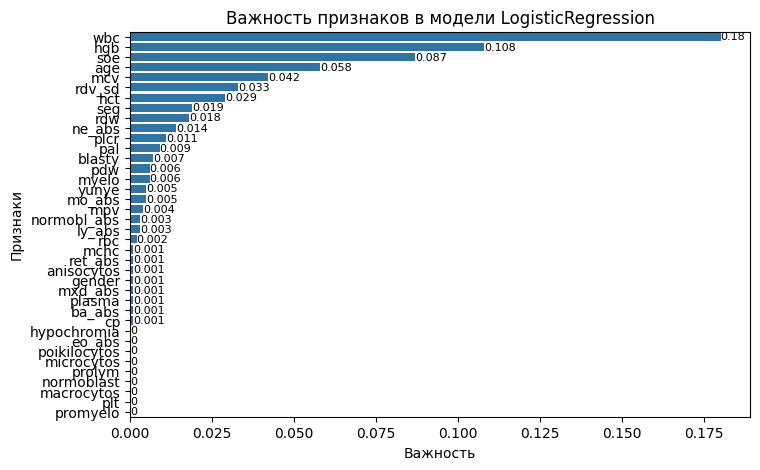

In [13]:
lr_params = {
    "penalty": [None, 'l2'],
    # "solver": ['lbfgs', 'liblinear'],
    # "l1_ratio": [0.5, 0.25],
    "max_iter": [1000, 2000],
    "class_weight": ['balanced'],
    "random_state": [42]
}
lr_bp = bp_gridsearch(X_train, y_train,
                   LogisticRegression(),
                   lr_params, 'accuracy', 3, True, 7)
best_lr = LogisticRegression(**lr_bp)
y_pred = best_lr.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели LogisticRegression с оптимальными гиперпараметрами:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['LogisticRegression_opt'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
plot_imp(df_clean.columns, np.abs(lr.coef_[0]), 'LogisticRegression')


# <span style="color:#66CCFF"> Случайный лес </span>


In [14]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
y_pred = rf.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели RandomForestClassifier с гиперпараметрами по умолчанию:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['RandomForest'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
# plot_imp(df_clean.columns, np.abs(rf.feature_importances_), 'RandomForestClassifier')

Метрики модели RandomForestClassifier с гиперпараметрами по умолчанию:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       118
           2       0.98      0.98      0.98        52
           3       0.99      0.99      0.99        75
           4       1.00      1.00      1.00        58

    accuracy                           0.99       385
   macro avg       0.99      0.99      0.99       385
weighted avg       0.99      0.99      0.99       385



Оптимальные гиперпараметры:
                   значение
class_weight       balanced
max_depth              None
min_samples_leaf          1
min_samples_split         2
n_estimators            200
random_state             42

Метрики модели RandomForestClassifier с оптимальными гиперпараметрами:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       118
           2       0.96      0.96      0.96        52
           3       0.99      0.99      0.99        75
           4       1.00      0.98      0.99        58

    accuracy                           0.99       385
   macro avg       0.99      0.99      0.99       385
weighted avg       0.99      0.99      0.99       385



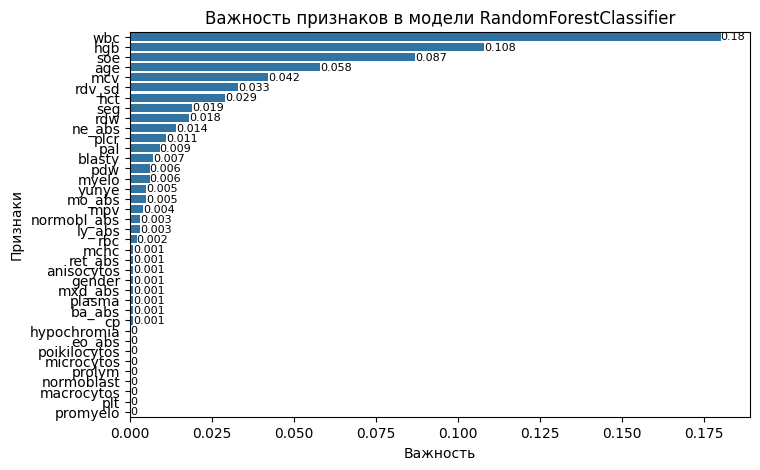

In [15]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced'],
    'random_state': [42]
}
rf_bp = bp_gridsearch(X_train, y_train,
                   RandomForestClassifier(),
                rf_params, 'accuracy', 3, True, 7)
best_rf = RandomForestClassifier(**rf_bp)
y_pred = best_rf.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели RandomForestClassifier с оптимальными гиперпараметрами:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['RandomForestClassifier_opt'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
plot_imp(df_clean.columns, np.abs(lr.coef_[0]), 'RandomForestClassifier')

# <span style="color:#66CCFF"> CatBoostClassifier </span>

Метрики модели CatBoostClassifier с гиперпараметрами по умолчанию:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       118
           2       1.00      1.00      1.00        52
           3       1.00      1.00      1.00        75
           4       1.00      1.00      1.00        58

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385



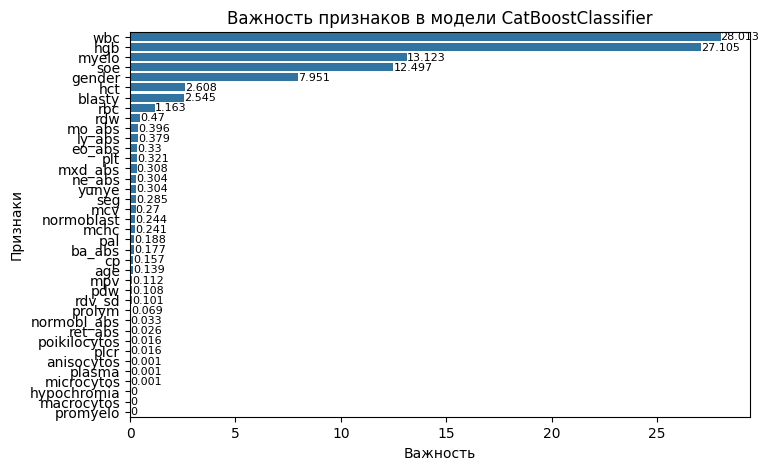

In [16]:

from catboost import CatBoostClassifier
catgb = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=False)
y_pred = catgb.fit(X_train, y_train).predict(X_test)
print(f'Метрики модели CatBoostClassifier с гиперпараметрами по умолчанию:\n{'=' * 66}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['CatBoost'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']
plot_imp(df_clean.columns, np.abs(catgb.feature_importances_), 'CatBoostClassifier')


# <span style="color:#66CCFF"> Нейронная сеть </span>


In [17]:
import tensorflow as tf
import keras
from keras.layers import Input, Dense
from keras.models import Sequential
from keras.backend import clear_session
from keras.callbacks import ModelCheckpoint

In [18]:
clear_session()

In [19]:
nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])
nn.summary()


2025-08-07 13:12:36.080715: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-08-07 13:12:36.080911: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-08-07 13:12:36.080920: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1754539956.081258 1105014 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1754539956.081806 1105014 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,189 (20.27 KB)

 Trainable params: 5,189 (20.27 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
nn.compile(
    loss='sparse_categorical_crossentropy',  # минимизируем кросс-энтропию
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("checkpoints/epoch_{epoch}.keras")
]


In [21]:
model_history = nn.fit(
                    X_train,
                    y_train,
                    batch_size=64,  # 64 объекта для подсчета градиента на каждом шаге
                    epochs=30,  # 10 проходов по датасету
                    callbacks=[callbacks],
                    validation_data=(X_test, y_test)
                    )


Epoch 1/30


2025-08-07 13:12:36.893334: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2061 - loss: 124.6592 - val_accuracy: 0.2519 - val_loss: 33.1259
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2794 - loss: 22.5789 - val_accuracy: 0.3584 - val_loss: 15.5993
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3365 - loss: 20.4408 - val_accuracy: 0.4000 - val_loss: 32.8911
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4291 - loss: 27.4998 - val_accuracy: 0.3532 - val_loss: 16.5148
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3852 - loss: 12.2962 - val_accuracy: 0.3792 - val_loss: 6.9340
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3746 - loss: 6.9995 - val_accuracy: 0.3922 - val_loss: 7.7934
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4621 - loss: 7.0455 - val_accuracy: 0.5403 - val_loss: 8.5106
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4878 - loss: 7.0443 - val_accuracy: 0.5662 - va

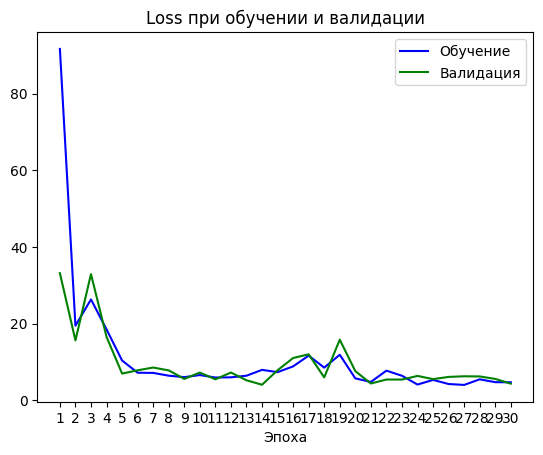

In [22]:
# Характеристики процесса обучения.
loss = model_history.history["loss"]
val_loss = model_history.history["val_loss"]
epochs = list(map(lambda epoch: epoch + 1, model_history.epoch))  # Преобразуем нумерацию эпох (с 0 -> с 1).

plt.figure()
plt.plot(epochs, loss, "b", label="Обучение")
plt.plot(epochs, val_loss, "g", label="Валидация")
plt.title("Loss при обучении и валидации")
plt.xlabel("Эпоха")
plt.xticks(range(1, 30 + 1))
# plt.ylim([0.2, 0.35])
plt.legend()
plt.show()


In [23]:
# Выбираем эпоху с лучшими показателями
nn = keras.saving.load_model('checkpoints/epoch_8.keras')
y_pred = nn.predict(X_test)
# y_pred = tf.squeeze(y_pred)
y_pred = np.argmax(y_pred, axis=1)
# np.array([1 if x >= 0.5 else 0 for x in y_pred])
print(f'Метрики модели NeuroNetwork:\n{'=' * 70}\n'
      f'{classification_report(y_test, y_pred)}')
# Сохраним метрики для сравнения
metrics_dict['NeuralNetwork'] = classification_report(y_test, y_pred,
                                            output_dict=True)['macro avg']

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Метрики модели NeuroNetwork:
              precision    recall  f1-score   support

           0       0.79      0.66      0.72        82
           1       0.62      0.87      0.72       118
           2       0.40      0.69      0.51        52
           3       0.09      0.03      0.04        75
           4       0.61      0.40      0.48        58

    accuracy                           0.57       385
   macro avg       0.50      0.53      0.49       385
weighted avg       0.52      0.57      0.52       385



In [24]:

pd.DataFrame.from_dict(metrics_dict, orient='index').sort_values(by=['recall', 'f1-score'], ascending=False).round(3)

,precision,recall,f1-score,support
CatBoost,1.000,1.000,1.000,385.0
RandomForest,0.993,0.993,0.993,385.0
RandomForestClassifier_opt,0.987,0.986,0.987,385.0
LogisticRegression_opt,0.858,0.854,0.854,385.0
LogisticRegression,0.724,0.720,0.721,385.0
NeuralNetwork,0.502,0.529,0.495,385.0


In [25]:
# проверим топ моделей на переобучение
overf_met_dict = {}

def overfit_metrics(model, model_label):
    """Расчет разницы метрик тестового и тренировочного 
    набора для оценки переобучения моделей
    """
    # Сделаем предсказание на тестовом и тренировочном наборе
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    if model_label == 'NeuralNetwork':
        y_pred_test = np.argmax(y_pred_test, axis=1)
        y_pred_train = np.argmax(y_pred_train, axis=1)

    # Расчитаем тестовые и тренировочные метрики
    test_metrics = classification_report(y_pred_test, y_test, output_dict=True)
    train_metrics = classification_report(y_pred_train, y_train, output_dict=True)
    # Вычислим разницу в метриках между тренировочным и тестовым набором
    overf_met_dict[model_label] = {
        'accuracy_dif': train_metrics['accuracy'] - test_metrics['accuracy'],
        'recall_dif': train_metrics['macro avg']['recall'] - test_metrics['macro avg']['recall'],
        'f1-score_dif': train_metrics['macro avg']['f1-score'] - test_metrics['macro avg']['f1-score']
        }
    
best_model_dict = {
                   'LR': lr,
                   'LR opt': best_lr,
                   'RF': rf,
                   'RF opt': best_rf,
                   'CatBoost': catgb,
                   'NeuralNetwork': nn, 
                   }

for l, m in best_model_dict.items():
    overfit_metrics(m, l)
pd.DataFrame.from_dict(overf_met_dict, orient='index').sort_values(by=['recall_dif', 'f1-score_dif']).round(3)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,accuracy_dif,recall_dif,f1-score_dif
NeuralNetwork,-0.011,-0.024,-0.012
LR,0.000,-0.009,-0.006
CatBoost,0.000,0.000,0.000
LR opt,0.005,0.000,0.006
RF,0.005,0.007,0.007
RF opt,0.010,0.013,0.013


# <span style="color:#66CCFF"> Выбор лучших моделей </span>


In [ ]:

# Сохраняем инференсы лучших моделей

import joblib
joblib.dump(catgb, 'inference/best_model.pkl')
joblib.dump(rf,'inference/rf.pkl')
joblib.dump(best_rf,'inference/rf_opt.pkl')

# model.save("inference/model_classification.keras")

['webapp/inference/rf_opt.pkl']